In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class julia:
  '''
  A class of Julia sets for z^d + c.
  parameters:
    height (int) - number of pixels along imaginary axis
    width (int) - number of pixels along real axis
    zoom (float) - radius of picture equals 1/zoom
    inverted_zoom (float) - when looking at the picture with infinity at the
      center (under the map z -> 1/z), the smallest purely real and purely
      imaginary values of inverted pictures are inverted_zoom
    c (complex number) - c in the function z^d + c
    d (int) - d in the function z^d + c
    folder - folder to store saved images
  dependencies:
    import numpy as np
  '''

  def __init__(self,height=500,width=500,zoom=0.8, inverted_zoom=0.5, c=complex(0,0), d=2, folder=None):
    self.filled_julia_set = np.zeros([height,width]) # numpy array of pixels showing filled Julia set
    self.julia_set = np.zeros([height,width]) # numpy array of pixels showing Julia set
    self.equilibrium_measure = np.zeros([height,width]) # numpy array of pixels showing equilibrium measure on Julia set
    self.c = c # c = complex(a,b) = a + bj, a complex number
    self.d = d # d integer: z**d+c
    self.portrait = np.zeros([height,width]) # numpy array of pixels showing something more customizable that julia_set or filled_julia_set
    self.height = height
    self.width = width
    self.zoom = zoom # radius of picture equals 1/zoom
    self.poly = lambda z: z**d + self.c # polynomial z**d + c
    self.nth_periodic_points = None # points of period n for poly
    self.nth_inverses = None # solutions to poly^{\circ n}(zeta)=zeta
    self.fatou_set = None #np.zeros([1,height,width]) # fatou_set will be a sequence of images as numpy arrays
    self.attr_fixed_pt = (1-np.sqrt(1-4*c))/2 # the attracting fixed point, provided c in main cardioid of Mandelbrot set
    self.inverted_filled_julia_set = np.zeros([height,width]) # filled julia set under the map z -> 1/z, with infinity at the origin
    self.inverted_julia_set = np.zeros([height,width]) # julia set under the map z -> 1/z, with infinity at the origin
    self.inverted_zoom = inverted_zoom # smallest purely real and purely imaginary values of inverted pictures are inverted_zoom
    self.exceptional_set = None #np.zeros([1,height,width]) # exceptional_set will be a sequence of images as numpy arrays
    self.cart_coords = np.zeros([height,width],dtype=complex) # the complex numbers associated with each pixel
    self.inv_cart_coords = np.zeros([height,width],dtype=complex) # the complex numbers associated with each pixel in inverted coordinates
    for x in range(width):
      for y in range(height):
        zy = (1-2.*y/height)
        zx = (2.*x/width-1)
        z = complex(zx,zy)
        self.cart_coords[y,x]=z/zoom
        z = z/inverted_zoom
        if np.abs(z)<1e-8:
          self.inv_cart_coords[y,x]=np.inf
        else:
          self.inv_cart_coords[y,x]=1/z
    if folder==None:
      self.folder = '/content/drive/My Drive/KState/thesis/EDTR/2019latex_source/defense/images/c='+str(self.c.real)+'_'+str(self.c.imag)+'_h='+str(self.height)+'_w='+str(self.width)+'_zoom='+str(self.zoom)+'_inv_zoom='+str(self.inverted_zoom)
      self.folder = self.folder.replace('.','')
    else:
      self.folder = folder

  def make_filled_julia(self,maxIter=100):
    '''make the julia set with an escape algorithm'''
    p = self.poly
    h,w = self.filled_julia_set.shape
    #zoom = self.zoom
    for x in range(w):
      for y in range(h):
        z = self.cart_coords[y,x]
        i = maxIter
        while (z.real)**2 + (z.imag)**2 < 4 and i > 1:
          z = p(z)
          i -= 1

        self.filled_julia_set[y,x] = (i>1)

  def make_julia(self):
    '''make the Julia set from the filled Julia set by removing pixels that are surrounded'''
    if np.max(self.filled_julia_set)==0:
      self.make_filled_julia()
    self.julia_set = self.filled_julia_set.copy()
    # check_pix in case we're looking at a border pixel
    def check_pix(i,j):
      try:
        return self.filled_julia_set[i,j]
      except:
        pass
    h,w = self.julia_set.shape
    for x in range(1,h-1):
      for y in range(1, w-1):
        if self.filled_julia_set[x,y] == 0:
          neighbors = set([check_pix(x,y-1),check_pix(x,y+1),check_pix(x-1,y),check_pix(x+1,y)])
          if 1 not in neighbors:
            self.julia_set[x,y] = 1

  def assign_portrait(self,array):
    '''initialize the portrait however you want by setting it equal to a copy of array'''
    self.portrait = array.copy()

  def plot_point(self,z,size=20,zoom=None):
    '''plot point z = complex(x,y) on portrait
    radius of point = sqrt(size)'''
    if zoom==None:
      zoom = self.zoom
    x = int((self.width/2)*(zoom*z.real+1))
    y = int((self.height/2)*(1-zoom*z.imag))

    clip = int(np.sqrt(size)+1)
    for j in range(y-clip,y+clip+1):
      for k in range(x-clip,x+clip+1):
        if (j-y)**2 + (k-x)**2 < size:
          self.portrait[j,k]=0

  def plot_points(self,points,size=20,zoom=None):
    '''plot points of the form complex(x,y) from the list points'''
    for point in points:
      self.plot_point(point,size,zoom)

  def get_nth_periodic_points(self,n=1,digits=15,maxsteps=50):
    '''get nth periodic points of self.poly'''
    from sympy import poly, compose, nroots
    from sympy.abc import z
    p = z**self.d + self.c
    g = p.copy()
    for k in range(n-1):
      g = compose(p,g)
    g = g-z
    roots = nroots(g,n=digits,maxsteps=maxsteps)
    self.nth_periodic_points = list(map(complex,roots))

  def make_periodic_points(self,iterations=6, size=6, digits=15,maxsteps=50):
    '''
    get nth periodic points of self.poly for n in range(1,iterations+1)
    and plot them on portrait
    '''
    if np.max(self.julia_set)==0:
      self.make_julia()
    self.periodic_points = np.zeros([iterations,self.height,self.width])
    for m in range(iterations):
      self.assign_portrait(self.julia_set)
      self.get_nth_periodic_points(n=m+1)
      self.plot_points(self.nth_periodic_points,size=size)
      self.periodic_points[m,:,:] = self.portrait

  def make_periodic_video(self,file_path=None,FPS=1):
    '''make an mp4 from self.fatou_set'''
    # convert data to uint8
    import cv2
    from cv2 import VideoWriter, VideoWriter_fourcc
    periodic_set = np.uint8((self.periodic_points/np.max(self.periodic_points))*255)
    num_frames,h,w = periodic_set.shape
    if file_path==None:
      file_path = self.folder + '_periodic_points_num_frames=' + str(num_frames) +'.mp4'
    periodic_set = np.tile(np.reshape(periodic_set,(-1,self.height,self.width,1)),(1,1,1,3))
    fourcc = VideoWriter_fourcc(*'MP4V')
    video = VideoWriter(file_path,fourcc,float(FPS),(self.width, self.height))
    for k in range(num_frames):
      video.write(periodic_set[k,:,:,:])
    video.release()

  def get_nth_inverses(self,zeta,n=1,digits=15,maxsteps=50):
    '''get solutions to self.poly^{\circ n}-zeta, where zeta=complex(a,b)'''
    from sympy import poly, compose, nroots
    from sympy.abc import z
    p = z**self.d + self.c
    g = p.copy()
    for k in range(n-1):
      g = compose(p,g)
    g = g-zeta
    roots = nroots(g,n=digits,maxsteps=maxsteps)
    self.nth_inverses = list(map(complex,roots))

  def make_inverse_points(self,zeta=None, iterations=6, size=6, digits=15,maxsteps=50):
    '''
    get nth inverse iterates of zeta under self.poly for n in range(1,iterations+1)
    and plot them on portrait
    '''
    if np.max(self.julia_set)==0:
      self.make_julia()
    if zeta==None:
      zeta = (1+np.sqrt(1-4*self.c))/2
    self.inverse_points = np.zeros([iterations,self.height,self.width])
    for m in range(iterations):
      self.assign_portrait(self.julia_set)
      self.get_nth_inverses(zeta=zeta,n=m+1,digits=digits,maxsteps=maxsteps)
      self.plot_points(self.nth_inverses,size=size)
      self.inverse_points[m,:,:] = self.portrait

  def make_inverse_video(self,file_path=None,FPS=1):
    '''make an mp4 from self.fatou_set'''
    # convert data to uint8
    import cv2
    from cv2 import VideoWriter, VideoWriter_fourcc
    inverse_set = np.uint8((self.inverse_points/np.max(self.inverse_points))*255)
    num_frames,h,w = inverse_set.shape
    if file_path==None:
      file_path = self.folder + '_inverse_points_num_frames=' + str(num_frames) +'.mp4'
    inverse_set = np.tile(np.reshape(inverse_set,(-1,self.height,self.width,1)),(1,1,1,3))
    fourcc = VideoWriter_fourcc(*'MP4V')
    video = VideoWriter(file_path,fourcc,float(FPS),(self.width, self.height))
    for k in range(num_frames):
      video.write(inverse_set[k,:,:,:])
    video.release()
########################
  def make_inv_per(self,zeta=None, iterations=6, size=6, digits=15,maxsteps=50):
    '''
    get the nth periodic points of self.poly along with the nth inverse iterates
    of zeta for n in range(1,iterations+1)
    '''
    if np.max(self.julia_set)==0:
      self.make_julia()
    if zeta==None:
      zeta = (1+np.sqrt(1-4*self.c))/2
    self.inv_per = np.zeros([iterations,self.height,self.width,3])
    for m in range(iterations):
      # periodic points in red
      self.assign_portrait(np.ones([self.height,self.width]))
      self.get_nth_periodic_points(n=m+1,digits=digits,maxsteps=maxsteps)
      self.plot_points(self.nth_periodic_points,size=size)
      red_pts = 1-self.portrait
      # inverse iterates in blue
      self.assign_portrait(np.ones([self.height,self.width]))
      self.get_nth_inverses(zeta=zeta,n=m+1,digits=digits,maxsteps=maxsteps)
      self.plot_points(self.nth_inverses,size=size)
      blue_pts = 1-self.portrait
      # red channel
      self.inv_per[m,:,:,0] = np.maximum(self.julia_set-blue_pts,red_pts)
      # blue channel
      self.inv_per[m,:,:,2] = np.maximum(self.julia_set-red_pts,blue_pts)
      # green channel
      self.inv_per[m,:,:,1] = np.amin(np.stack([1-blue_pts,1-red_pts,self.julia_set]),axis=0)
##########################
  def make_inv_per_video(self,file_path=None,FPS=1):
    '''make an mp4 from self.inv_per'''
    # convert data to uint8
    import cv2
    from cv2 import VideoWriter, VideoWriter_fourcc
    inv_per = np.uint8((self.inv_per/np.max(self.inv_per))*255)
    num_frames,h,w,_ = inv_per.shape
    if file_path==None:
      file_path = self.folder + '_inv_per_num_frames=' + str(num_frames) +'.mp4'
    fourcc = VideoWriter_fourcc(*'MP4V')
    video = VideoWriter(file_path,fourcc,float(FPS),(self.width, self.height))
    for k in range(num_frames):
      video.write(inv_per[k,:,:,:])
    video.release()

  def make_equilibrium_measure(self,iterations=100,delta=0.1):
    '''get the equilibrium measure of the Julia set by using a Monte Carlo method
    based on the Brownian motion interpretation of equilibrium measure'''
    if np.max(self.julia_set)==0:
      self.make_julia()
    # get the distance of the furthest point of the Julia set from 0
    center = (self.width/2,self.height/2)
    black = np.where(self.julia_set==0)
    black = np.stack([black[0],black[1]],axis=1)
    pix = max(black, key=lambda x: (x[0]-center[0])**2+(x[1]-center[1])**2)
    z = self.cart_coords[pix[1],pix[0]]
    radius = np.abs(z)
    for k in range(iterations):
      # Brownian motion starting at infinity is equally likely to first hit anywhere
      # on the circle of radius 2 centered at 0.  It continues from there until it
      # hits the julia set
      theta = np.random.uniform(0,2*np.pi)
      w = radius*np.exp(complex(0,theta))
      # convert point w on circle to pixel coordinates
      x = int((self.width/2)*(self.zoom*w.real+1))
      y = int((self.height/2)*(1-self.zoom*w.imag))
      # check that [i,j] is in frame and not on the filled Julia set
      def in_frame(i,j):
        try:
          return self.filled_julia_set[i,j] > 0
        except:
          return False

      # perform the random walk
      # stop if we're on the filled Julia set or if we've gone too far astray
      while in_frame(y,x):
        move = np.random.choice(4)
        neighbors = [(x-1,y),(x+1,y),(x,y-1),(x,y+1)]
        a,b = neighbors[move]
        # if we're not moving outside the circle, move.  Otherwise, stay put
        try:
          if np.abs(self.cart_coords[b,a]) < (radius+delta):
            x,y=a,b
        except:
          pass
      # if [x,y] is in frame, then it's on the Julia set
      try:
        self.equilibrium_measure[y,x]+=1
      except:
        continue

  def make_fatou_set(self,iterations=3,delta=0.2,R=100):
    '''
    make a video for the fatou set in the form of stacked numpy arrays.
    only works for c in main cardioid, because it assumes an attracting fixed point
    if delta is too small, this will look ugly.  delta depends on self.c
    '''
    # check that c is in the main cardioid
    if np.abs(2*self.attr_fixed_pt) >= 1:
      import warnings
      warnings.warn('This function assumes self.c is in the main cardioid of the Mandelbrot set, but it is not in this case',UserWarning)
    if np.max(self.julia_set)==0:
      self.make_julia()
    z_0 = self.attr_fixed_pt
    p = self.poly
    h = self.height
    w = self.width
    zoom = self.zoom
    # one frame for each iteration
    fatou_set = np.ones([iterations,h,w])
    for n in range(iterations):
      for x in range(w):
        for y in range(h):
          # convert pixel to Cartesian coordinates
          #zy = (1-2.*y/h)/zoom
          #zx = (2.*x/w -1)/zoom
          #z = complex(zx,zy)
          z = self.cart_coords[y,x]
          # iteratete n times
          for k in range(n):
              z = p(z)
              if np.abs(z)>R:
                break
          # check if it's close to the fixed point
          if np.abs(z-z_0) < delta or np.abs(z)>R:
            fatou_set[n,y,x]=0
    self.fatou_set = np.zeros([iterations+1,h,w])
    # make the points closer to the Julia set lighter
    for n in range(iterations+1):
      self.fatou_set[n,:,:] = np.sum(fatou_set[iterations-n:,:,:],axis=0)

  def make_fatou_video(self,file_path=None,FPS=1):
    '''make an mp4 from self.fatou_set'''
    # convert data to uint8
    import cv2
    from cv2 import VideoWriter, VideoWriter_fourcc
    fatou_set = np.uint8((self.fatou_set/np.max(self.fatou_set))*255)
    num_frames,h,w = fatou_set.shape
    if file_path==None:
      file_path = self.folder + '_fatou_set_num_frames=' + str(num_frames) +'.mp4'
    fatou_set = np.tile(np.reshape(fatou_set,(-1,self.height,self.width,1)),(1,1,1,3))
    fourcc = VideoWriter_fourcc(*'MP4V')
    video = VideoWriter(file_path,fourcc,float(FPS),(self.width, self.height))
    for k in range(num_frames):
      video.write(fatou_set[k,:,:,:])
    video.release()

  def make_inverted_filled_julia(self,maxIter=100):
    '''show the Julia set under the map z -> 1/z, with infinity at the origin'''
    p = self.poly
    h = self.height
    w = self.width
    for x in range(w):
      for y in range(h):
        z = self.inv_cart_coords[y,x]
        i = maxIter
        while (z.real)**2 + (z.imag)**2 < 4 and i > 1:
          z = p(z)
          i -= 1
        self.inverted_filled_julia_set[y,x] = (i>1)

  def make_inverted_julia(self):
    '''make the Julia set from the filled Julia set by removing pixels that are surrounded'''
    if np.max(self.inverted_filled_julia_set)==0:
      self.make_inverted_filled_julia()
    self.inverted_julia_set = self.inverted_filled_julia_set.copy()
    h = self.height
    w = self.width
    # check_pix in case we're looking at a border pixel
    def check_pix(i,j):
      try:
        return self.inverted_filled_julia_set[i,j]
      except:
        pass
    for x in range(h):
      for y in range(w):
        if self.inverted_filled_julia_set[x,y] == 0:
          neighbors = set([check_pix(x,y-1),check_pix(x,y+1),check_pix(x-1,y),check_pix(x+1,y)])
          if 1 not in neighbors:
            self.inverted_julia_set[x,y] = 1

  def make_exceptional(self,a=None, delta=0.2,epsilon=0.02, pix_eps=2, iterations=5,resolution=100):
    '''
    make a video for the exceptional set in the form of stacked numpy arrays.
    assumes initial domain is contained entirely in frame
    '''
    def in_hull(p, hull):
      """
      Test if points in `p` are in `hull`

      `p` should be a `NxK` coordinates of `N` points in `K` dimensions
      `hull` is either a scipy.spatial.Delaunay object or the `MxK` array of the
      coordinates of `M` points in `K`dimensions for which Delaunay triangulation
      will be computed
      """
      from scipy.spatial import Delaunay
      try:
        if not isinstance(hull,Delaunay):
            hull = Delaunay(hull)
        return hull.find_simplex(p)>=0
      except:
        return self.inverted_julia_set

    if np.max(self.inverted_julia_set)==0:
      self.make_inverted_julia()
    p = self.poly
    h = self.height
    w = self.width
    # get a point in the Julia set
    if a==None:
      # get the pixel of a point in the Julia set
      black = np.where(self.inverted_julia_set==0)
      pix = np.random.randint(len(black[0]))
      pix = (black[0][pix],black[1][pix])
      # convert pixel to Cartesian coordinates
      a = self.inv_cart_coords[pix[0],pix[1]]
    # one frame for each iteration
    exceptional_set = np.ones([iterations,h,w])
    # get real 2D coords instead of complex for compatibility with in_hull()
    real_coords = np.stack([julia1.inv_cart_coords.real,julia1.inv_cart_coords.imag],axis=2)
    # get a circle around a in normal coordinates, and map it forward
    theta = np.linspace(0,2*np.pi,resolution,dtype=complex)
    zeta = a - delta*np.exp(theta*1j)  # why not 1/a?
    for n in range(iterations):
      # make boundary forward
      if n>0:
        zeta = p(zeta)
      # convert to real Cartesian coords
      points = np.stack([zeta.real, zeta.imag],axis=1)
      # check which points fall within boundary of image
      exceptional_set[n,:,:] = 1-in_hull(real_coords,points)
    self.exceptional_set = np.ones_like(exceptional_set)
    for n in range(iterations):
      for x in range(w):
        for y in range(h):
          if self.inverted_julia_set[y,x]==0:
            self.exceptional_set[n,y,x]=0
            continue
          for k in range(n+1):
            if exceptional_set[k,y,x]==0:
              self.exceptional_set[n,y,x]=0
    # make sure infinity is visible
    for x in range(int(w/2)-3,int(w/2)+4):
      for y in range(int(h/2)-3,int(h/2)+4):
        if (x-int(w/2))**2+(y-int(h/2))**2 < 6:
          for k in range(iterations):
            self.exceptional_set[k,y,x]=1

  def make_exceptional_video(self,file_path=None,FPS=1):
    '''make an mp4 from self.exceptional_set'''
    # convert data to uint8
    import cv2
    from cv2 import VideoWriter, VideoWriter_fourcc
    exceptional_set = np.uint8((self.exceptional_set*255))
    num_frames,h,w = exceptional_set.shape
    if file_path==None:
      file_path = self.folder + '_exceptional_set_num_frames=' + str(num_frames) +'.mp4'
    exceptional_set = np.tile(np.reshape(exceptional_set,(-1,self.height,self.width,1)),(1,1,1,3))
    fourcc = VideoWriter_fourcc(*'MP4V')
    video = VideoWriter(file_path,fourcc,float(FPS),(self.width, self.height))
    for k in range(num_frames):
      video.write(exceptional_set[k,:,:,:])
    video.release()

  def save_images(self,colormap='rainbow_r'):
    '''
    save the pictures
    '''
    import matplotlib.pyplot as plt

    if np.max(self.filled_julia_set)==0:
      self.make_filled_julia()
    plt.imsave(self.folder + '_filled_julia_set.png',self.filled_julia_set,cmap='gray')

    if np.max(self.julia_set)==0:
      self.make_julia()
    plt.imsave(self.folder + '_julia_set.png',self.julia_set,cmap='gray')

    if np.max(self.equilibrium_measure)==0:
      self.make_equilibrium_measure(iterations=int(self.height*self.width/4))
    plt.imsave(self.folder + '_equilibrium_measure.png',self.equilibrium_measure,cmap=colormap)




In [ ]:
julia2 = julia(height=200,width=200,inverted_zoom=0.3,zoom=0.8, c=0.4+0.5j,d=3)

In [ ]:
julia2.make_julia()

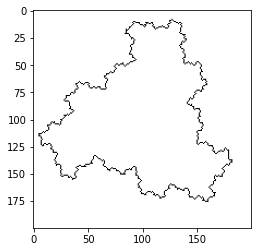

In [ ]:
plt.imshow(julia2.julia_set,cmap='gray')

In [ ]:
julia2.make_inv_per(iterations=4)

In [ ]:
julia2.make_inv_per_video(file_path='hi.mp4')

In [ ]:
julia2.make_equilibrium_measure(iterations=10000)

In [ ]:
julia2.poly(3)

(27.4+0.5j)

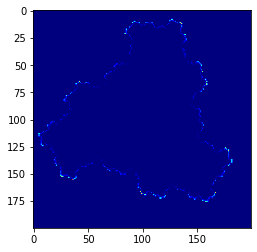

In [ ]:
plt.imshow(julia2.equilibrium_measure,cmap='jet')

In [ ]:
plt.imsave('julia_set_c=-1.png',julia2.julia_set,cmap='gray')

In [ ]:
julia2.make_inverted_julia()

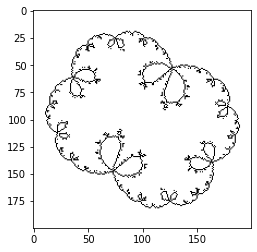

In [ ]:
plt.imshow(julia2.inverted_julia_set,cmap='gray')

In [ ]:
plt.imsave('inv_julia_set_c=-012p075j.png',julia2.inverted_julia_set,cmap='gray')

In [ ]:
plt.imsave('julia_set_c=-012p075j.png',julia2.julia_set,cmap='gray')

In [ ]:
julia2.make_exceptional(iterations=15,delta=0.1)

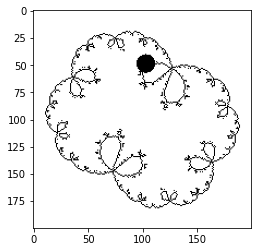

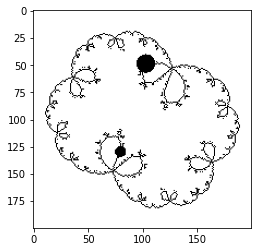

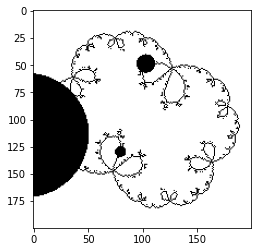

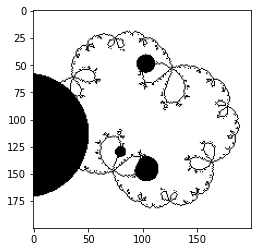

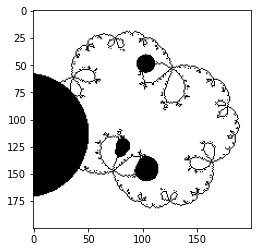

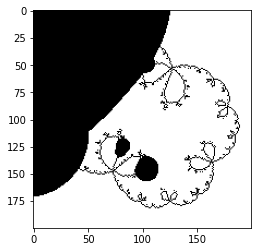

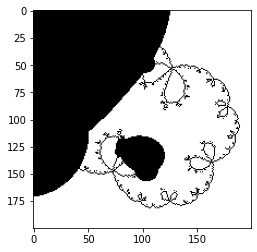

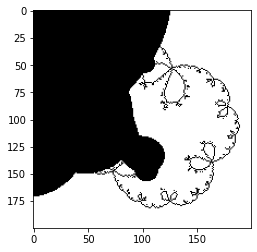

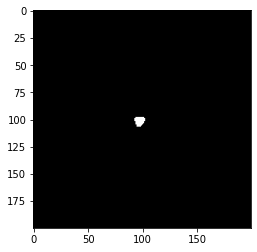

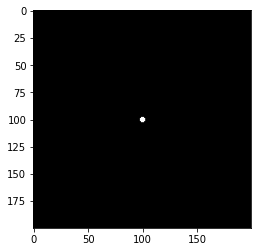

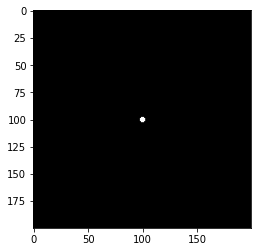

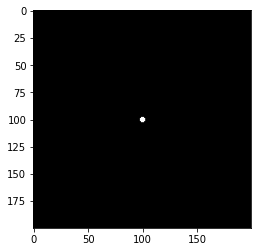

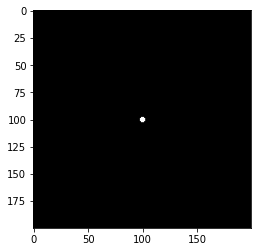

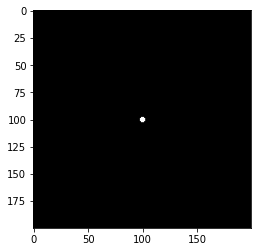

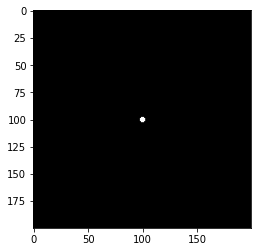

In [ ]:
for i in range(15):
  plt.figure()
  plt.imshow(julia2.exceptional_set[i],cmap='gray')
  plt.show()

In [ ]:
for i in range(10):
  plt.imsave('exceptional_set_c=-012p075j-'+str(i)+'.png', julia2.exceptional_set[i],cmap='gray')

In [ ]:
hi = julia2.exceptional_set.copy()

In [ ]:
plt.imsave('julia_set_c=-07.png',julia2.julia_set,cmap='gray')

In [ ]:
julia2.make_equilibrium_measure(iterations=100000)

In [ ]:
plt.imsave('eq_meas_c=-03p-05j.png',julia2.equilibrium_measure,cmap='jet')

In [ ]:
np.save('eq_meas_c=-03p-05j.npy',julia2.equilibrium_measure)

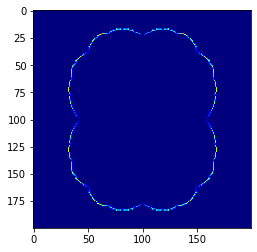

In [ ]:
plt.imshow(np.load('/content/eq_meas_c=02.npy'),cmap='jet')

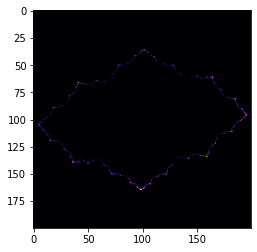

In [ ]:
plt.imshow(julia2.equilibrium_measure,cmap='magma')

In [ ]:
plt.imsave('eq_meas_c=-05p-01j.png',julia2.equilibrium_measure,cmap='jet')

In [ ]:
plt.imsave('eq_meas_gray_c=-05-01j.png',julia2.equilibrium_measure,cmap='gray')

In [ ]:
julia2.make_periodic_points()

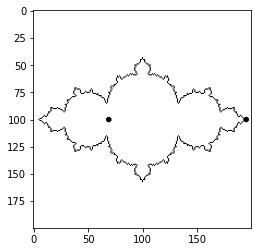

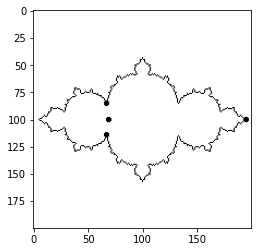

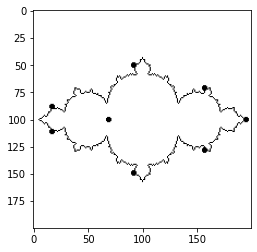

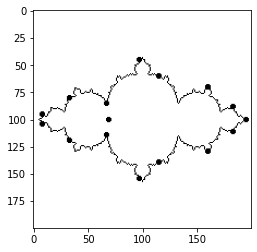

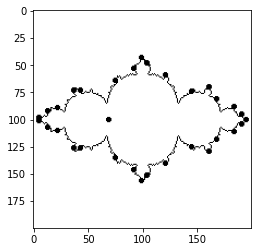

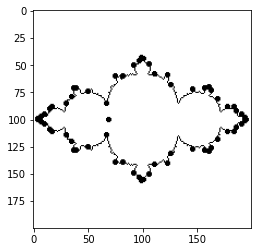

In [ ]:
for i in range(6):
  plt.figure()
  plt.imshow(julia2.periodic_points[i],cmap='gray')
  plt.show()

In [ ]:
for i in range(6):
  plt.imsave('per-c=-07-'+str(i)+'.png',julia2.periodic_points[i],cmap='gray')

In [ ]:
a=(1-np.sqrt(1-4*(-0.7)))/2

In [ ]:
a

-0.47467943448089633

In [ ]:
julia2.make_inverse_points(zeta=-0.1+0.3j)

In [ ]:
for i in range(6):
  plt.imsave('inv-c=02-a=-01p03j-'+str(i)+'.png',julia2.inverse_points[i],cmap='gray')

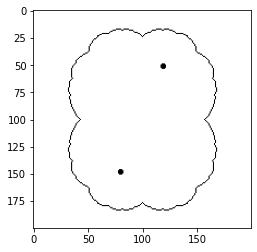

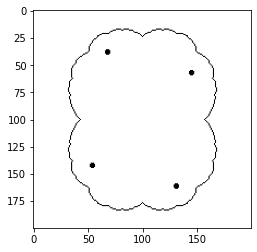

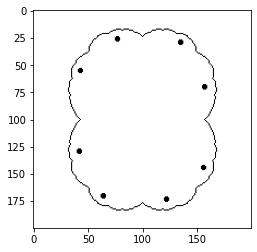

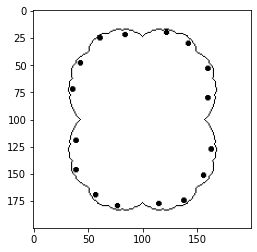

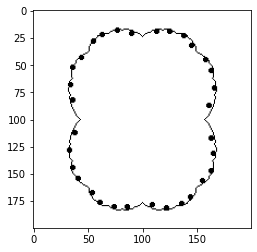

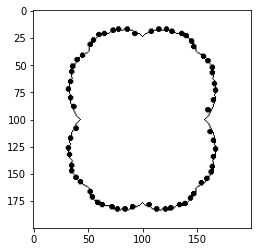

In [ ]:
for i in range(6):
  plt.figure()
  plt.imshow(julia2.inverse_points[i],cmap='gray')
  plt.show()

In [ ]:
julia1.make_inv_per(size=20)

TypeError: ignored

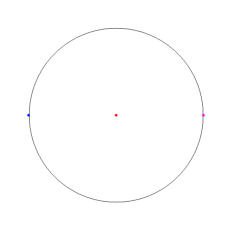

In [ ]:
for i in range(6):
  plt.figure()
  plt.imshow(julia1.inv_per[i])
  plt.axis('off')
  #plt.savefig('hi.png')
  plt.imsave('inv-per-c=0-'+str(i)+'.png')


In [ ]:
julia1.make_equilibrium_measure(iterations=1000)

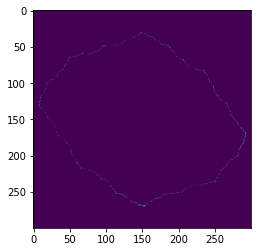

In [ ]:
plt.imshow(julia1.equilibrium_measure)

In [ ]:
class julia_array:
  '''
  A class of arrays containing Julia sets for z^2 + c, for multiple values of c.
  Just for the sake of easy concatenation of images.
  c_array should be a 2-dimensional numpy array
  dependencies:
    import numpy as np
  '''
  def __init__(self,height=500,width=500,zoom=0.8, inverted_zoom=0.5, c_array=np.array([complex(0,0)]),folder=None):
    self.height = height # the height to be used for each julia class
    self.width = width # the width to be used for each julia class
    self.zoom = zoom # the zoom to be used for each julia class
    self.inverted_zoom = inverted_zoom # the inverted_zoom to be used for each julia class
    self.c_array = c_array # an array of the c values to be used for each julia class
    self.grid = np.zeros_like(c_array,dtype=object) # the array of julia objects
    it = np.nditer(self.grid, flags=['multi_index','refs_ok'])
    for _ in it:
      self.grid[it.multi_index] = julia(height=height,width=width,zoom=zoom,inverted_zoom=inverted_zoom,c=c_array[it.multi_index],folder=None)
    if folder==None:
      self.folder=''
    else:
      self.folder=folder

  def make_filled_julia(self,maxIter=100):
    '''make the filled julia set for each array with an escape algorithm'''
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.grid[it.multi_index].make_filled_julia(maxIter=maxIter)
    m,n = self.grid.shape
    h = self.height
    w = self.width
    self.filled_julia_set = np.zeros([m*self.height,n*self.width])
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.filled_julia_set[h*it.multi_index[0]:h*(it.multi_index[0]+1),w*it.multi_index[1]:w*(it.multi_index[1]+1)] = self.grid[it.multi_index].filled_julia_set

  def make_julia(self):
    '''make the Julia sets from the filled Julia sets by removing pixels that are surrounded'''
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.grid[it.multi_index].make_julia()
    m,n = self.grid.shape
    h = self.height
    w = self.width
    self.julia_set = np.zeros([m*h,n*w])
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.julia_set[h*it.multi_index[0]:h*(it.multi_index[0]+1),w*it.multi_index[1]:w*(it.multi_index[1]+1)] = self.grid[it.multi_index].julia_set

  def make_periodic_points(self,iterations=6, size=6, digits=15,maxsteps=50):
    '''
    get nth periodic points of self.poly for n in range(1,iterations+1)
    and plot them on julia.portrait for each julia class
    '''
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.grid[it.multi_index].make_periodic_points(iterations=iterations,size=size,digits=digits,maxsteps=maxsteps)
    h = self.height
    w = self.width
    m,n = self.grid.shape
    self.periodic_points = np.zeros([iterations,m*h,n*w])
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.periodic_points[:,h*it.multi_index[0]:h*(it.multi_index[0]+1),w*it.multi_index[1]:w*(it.multi_index[1]+1)] = self.grid[it.multi_index].periodic_points

  def make_inverse_points(self,zeta=None, iterations=6, size=6, digits=15,maxsteps=50):
    '''
    get nth inverse iterates of zeta under self.poly for n in range(1,iterations+1)
    and plot them on julia.portrait for each julia class
    '''
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.grid[it.multi_index].make_inverse_points(zeta=zeta,iterations=iterations,size=size,digits=digits,maxsteps=maxsteps)
    h = self.height
    w = self.width
    m,n = self.grid.shape
    self.inverse_points = np.zeros([iterations,m*h,n*w])
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.inverse_points[:,h*it.multi_index[0]:h*(it.multi_index[0]+1),w*it.multi_index[1]:w*(it.multi_index[1]+1)] = self.grid[it.multi_index].inverse_points

  def make_inv_per(self,zeta=None, iterations=6, size=6, digits=15,maxsteps=50):
    '''
    get the nth periodic points of self.poly along with the nth inverse iterates
    of zeta for n in range(1,iterations+1)
    '''
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.grid[it.multi_index].make_inv_per(zeta=zeta,iterations=iterations,size=size,digits=digits,maxsteps=maxsteps)
    h = self.height
    w = self.width
    m,n = self.grid.shape
    self.inv_per = np.zeros([iterations,h*m,w*n,3])
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.inv_per[:,h*it.multi_index[0]:h*(it.multi_index[0]+1),w*it.multi_index[1]:w*(it.multi_index[1]+1),:] = self.grid[it.multi_index].inv_per

  def make_gray_video(self,whatever,file_path=None,FPS=1):
    '''make an mp4 from self.whatever'''
    # convert data to uint8
    import cv2
    from cv2 import VideoWriter, VideoWriter_fourcc
    video_set = np.uint8((whatever/np.max(whatever))*255)
    num_frames,h,w = video_set.shape
    if file_path==None:
      file_path = self.folder + '_whatever_num_frames=' + str(num_frames) +'.mp4'
    video_set = np.tile(np.reshape(video_set,(-1,h,w,1)),(1,1,1,3))
    fourcc = VideoWriter_fourcc(*'MP4V')
    video = VideoWriter(file_path,fourcc,float(FPS),(w, h))
    for k in range(num_frames):
      video.write(video_set[k,:,:,:])
    video.release()

  def make_color_video(self,whatever,file_path=None,FPS=1):
    '''make an mp4 from self.whatever'''
    # convert data to uint8
    import cv2
    from cv2 import VideoWriter, VideoWriter_fourcc
    video_set = np.uint8((whatever/np.max(whatever))*255)
    num_frames,h,w,_ = video_set.shape
    if file_path==None:
      file_path = self.folder + '_whatever_num_frames=' + str(num_frames) +'.mp4'
    fourcc = VideoWriter_fourcc(*'MP4V')
    video = VideoWriter(file_path,fourcc,float(FPS),(w, h))
    for k in range(num_frames):
      video.write(video_set[k,:,:,:])
    video.release()

  def make_equilibrium_measure(self,iterations=10000,delta=0.1):
    '''get the equilibrium measure of the Julia set by using a Monte Carlo method
    based on the Brownian motion interpretation of equilibrium measure'''
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.grid[it.multi_index].make_equilibrium_measure(iterations=iterations,delta=delta)
    m,n = self.grid.shape
    h = self.height
    w = self.width
    self.equilibrium_measure = np.zeros([m*self.height,n*self.width])
    it = np.nditer(self.grid,flags=['multi_index','refs_ok'])
    for _ in it:
      self.equilibrium_measure[h*it.multi_index[0]:h*(it.multi_index[0]+1),w*it.multi_index[1]:w*(it.multi_index[1]+1)] = self.grid[it.multi_index].equilibrium_measure


In [ ]:
np.array([[0+0.2j,0.2+0.2j],[0+0j,0.2+0j]])

In [ ]:
cx,cy = np.meshgrid(np.arange(-0.6,0.4,0.2),np.arange(-0.4,0.6,0.2))
c_array = cx + cy*1j

In [ ]:
jarray = julia_array(height=200,width=200,c_array=np.array([[0+0.2j,0.2+0.2j],[0+0j,0.2+0j]]),zoom=0.8)

In [ ]:
jarray.make_inv_per(iterations=6)

In [ ]:
for i in range(6):
  plt.imsave('inv-per-grid-'+str(i)+'.png',jarray.inv_per[i])

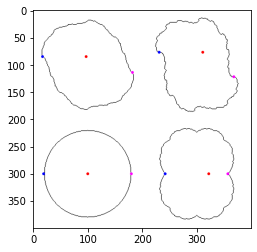

In [ ]:
plt.imshow(jarray.inv_per[0])

In [ ]:
jarray.make_color_video(jarray.inv_per,file_path='25inv_per.mp4')

In [ ]:
jarray.make_filled_julia()

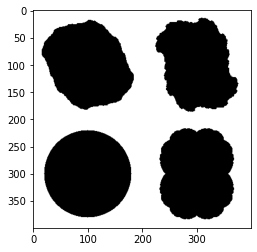

In [ ]:
plt.imshow(jarray.filled_julia_set,cmap='gray')

In [ ]:
jarray.make_inv_per()

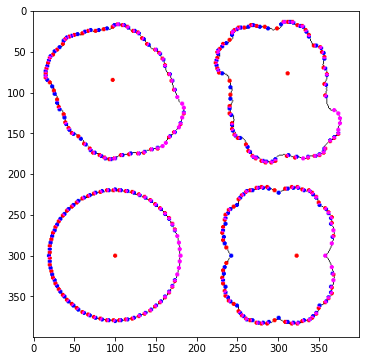

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(jarray.inv_per[5])
plt.show()

In [ ]:
jarray.make_julia()

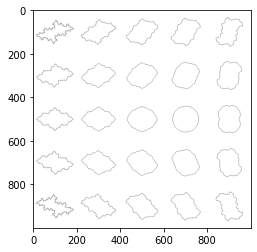

In [ ]:
plt.imshow(jarray.julia_set,cmap='gray')

In [ ]:
jarray.make_equilibrium_measure(iterations=10000)

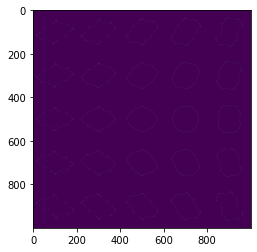

In [ ]:
plt.imshow(jarray.equilibrium_measure)